<a href="https://colab.research.google.com/github/sandamali-2002/4th-sem/blob/main/tensoflor_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets


In [ ]:
import opendatasets as od
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [ ]:
od.download("https://www.kaggle.com/datasets/andonians/random-linear-regression")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: chandimasandamali 
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andonians/random-linear-regression


100%|██████████| 7.63k/7.63k [00:00<00:00, 13.6MB/s]

In [ ]:
data=pd.read_csv("random-linear-regression/test.csv")

In [ ]:
data.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [ ]:
data.shape

(300, 2)

In [ ]:
x=data["x"]
y=data["y"]

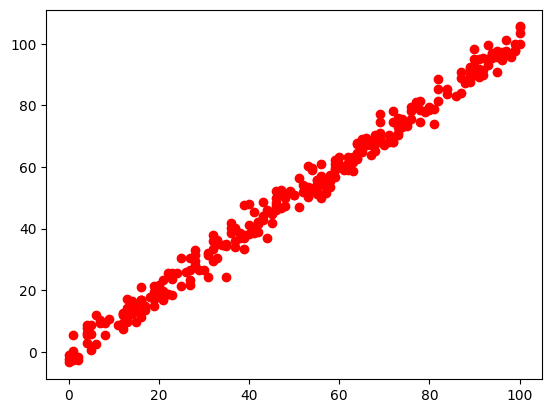

In [ ]:
plt.scatter(x,y,color='red')

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape,
x_test.shape


(60,)

/tmp/ipython-input-231804214.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


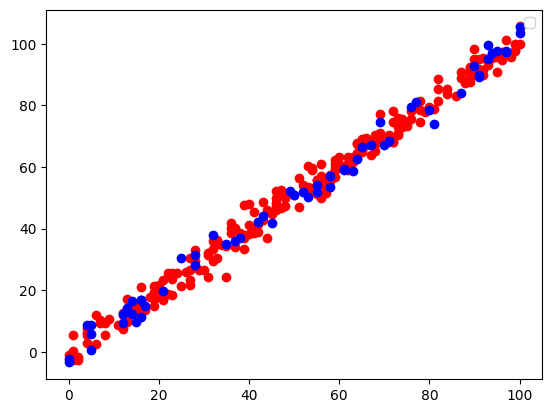

In [ ]:
plt.scatter(x_train,y_train,color='red')
plt.scatter(x_test,y_test,color='blue')
plt.legend()
plt.show()

model building

In [ ]:
#create a model
model=tf.keras.Sequential([
      tf.keras.layers.Dense(4,input_shape=(1,)),
      tf.keras.layers.Dense(1)
])

#compile
model.compile(loss=tf.keras.losses.MAE,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae']
)

#training
epoc=4
model.fit(tf.expand_dims(x_train,axis=1),y_train,epochs=epoc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 52.3195 - mae: 52.3195
Epoch 2/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 26.0159 - mae: 26.0159
Epoch 3/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 28.1738 - mae: 28.1738
Epoch 4/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.2394 - mae: 21.2394


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (64.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
y_predict=model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


In [ ]:
y_predict[:5]

array([[77.93176 ],
       [65.82424 ],
       [81.39105 ],
       [ 4.421864],
       [78.796585]], dtype=float32)

In [ ]:
y_test.head(5)

,y
203,92.887723
266,79.503415
152,97.001484
9,8.746748
233,89.739520


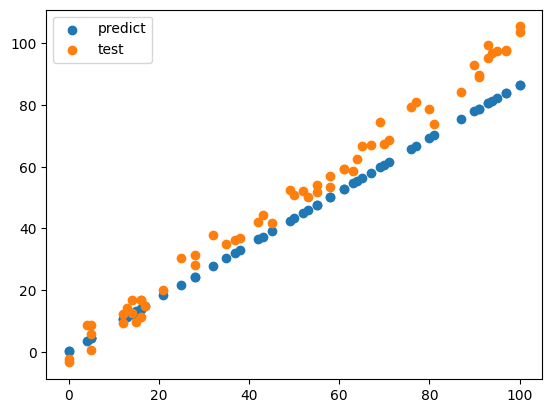

In [ ]:
plt.scatter(x_test,y_predict,label='predict')
plt.scatter(x_test,y_test,label='test')
plt.legend()
plt.show()

In [ ]:
model.evaluate(x_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.5307 - mae: 7.5307 


[7.256543159484863, 7.256543159484863]

In [ ]:
mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_metric.update_state(y_test, tf.squeeze(y_predict))
mae = mae_metric.result()

mae.numpy()



np.float32(7.2565417)

In [ ]:
y_predict.shape

(60, 1)

In [ ]:
y_test.shape

(60,)